In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [6]:
X, y = make_classification(n_samples=1000, n_features=7,
                           n_classes=2,
                           random_state=RANDOM_STATE)

In [7]:
pd.DataFrame(X).head(3)

,0,1,2,3,4,5,6
0,0.496820,-1.345871,-0.819258,-0.303726,0.331740,-0.293255,-0.899756
1,-0.319070,-0.514783,0.243530,-0.094824,0.128477,-0.854750,1.693724
2,-0.776133,-1.395449,-0.707911,-0.057395,-0.662009,0.897203,0.935878


In [8]:
pd.DataFrame(y).head(3)

,0
0,0
1,0
2,1


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                               test_size=0.25,
                                               random_state=RANDOM_STATE)

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
model.predict_proba(X_test)[:10, :]

array([[3.66437360e-04, 9.99633563e-01],
       [8.56556159e-01, 1.43443841e-01],
       [4.06939727e-01, 5.93060273e-01],
       [6.95824366e-02, 9.30417563e-01],
       [1.92974350e-01, 8.07025650e-01],
       [1.57843867e-01, 8.42156133e-01],
       [8.57666705e-01, 1.42333295e-01],
       [6.10152920e-01, 3.89847080e-01],
       [8.05992523e-01, 1.94007477e-01],
       [1.61919810e-01, 8.38080190e-01]])

In [14]:
y_scores = model.predict_proba(X_test)[:, 1]

In [16]:
y_scores[:10]

array([0.99963356, 0.14344384, 0.59306027, 0.93041756, 0.80702565,
       0.84215613, 0.1423333 , 0.38984708, 0.19400748, 0.83808019])

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [18]:
thresholds[:10]

array([       inf, 0.99987818, 0.94078469, 0.93423095, 0.90411272,
       0.88344088, 0.84854957, 0.84743548, 0.74121619, 0.73705703])

In [22]:
print("FPR:\n", fpr[:10], "\n"*2, "TPR:\n", tpr[:10])

FPR:
 [0.         0.         0.         0.00819672 0.00819672 0.02459016
 0.02459016 0.03278689 0.03278689 0.04098361] 

 TPR:
 [0.        0.0078125 0.375     0.375     0.5       0.5       0.5546875
 0.5546875 0.734375  0.734375 ]


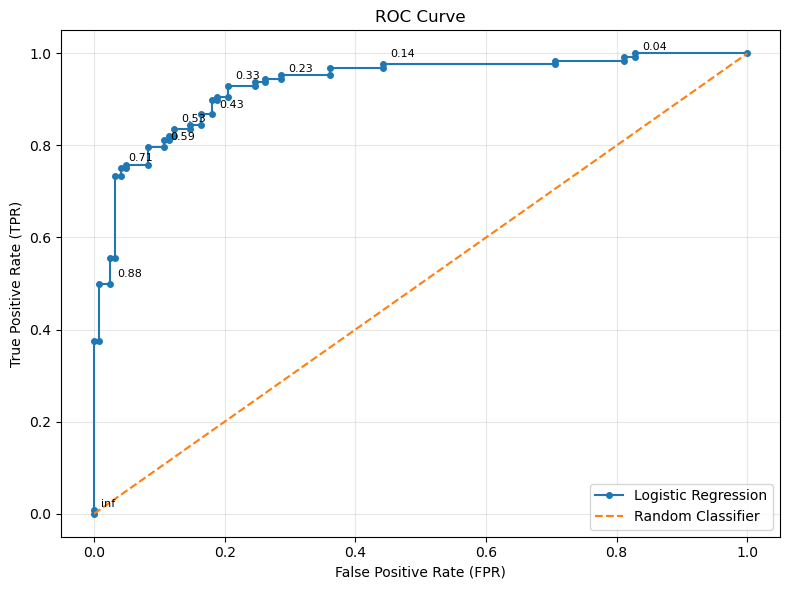

In [31]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, marker='o', markersize=4, label='Logistic Regression')
plt.plot([0, 1], [0, 1], '--', label='Random Classifier')

# Annotate every 5th point
for i in range(0, len(thresholds), 5):
    plt.annotate(
        f'{thresholds[i]:.2f}',
        (fpr[i], tpr[i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
score = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC Score = {score}")

ROC-AUC Score = 0.9325051229508197
